# Multi-Anchor Spatial ResNet Object Detector (Stage 7)

Trains `ObjectDetectorResNet` with a multi-anchor grid spatial head ($S \times S \times K$) to predict bounding boxes and character classes.
Each spatial cell predicts $K=3$ anchor slots `[x, y, w, h, conf]`, using **Focal Loss** for objectness confidence and Aligned IoU loss for localization.

**Pipeline:**  
`get_detection_loaders` → `ObjectDetectorResNet` ($K=3$) → `DetectionLoss` (Focal Loss) → `fit()`


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch

from utils.dataset import get_detection_loaders, S, K
from generator.dataset import EMNIST_CLASS_NAMES
from utils.trainer import fit, evaluate_detection, evaluate_detection_sweep
from utils.visualizer import Visualizer
from utils.callbacks import ModelCheckpoint
from utils.losses import DetectionLoss
from models import get_detector

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT_DIR    = '../data'
BATCH_SIZE  = 198
EPOCHS      = 60
GRID_SIZE   = S        # 14x14 grid
CONF_THRESH = 0.5     # sigmoid threshold at inference
MODEL_SIZE  = 'n'
CLASS_NAMES = EMNIST_CLASS_NAMES['bymerge']
NUM_ANCHORS = K
USE_FOCAL_LOSS = True
FOCAL_ALPHA    = 0.25
FOCAL_GAMMA    = 2.0
USE_POS_WEIGHT = False

print(f'Device   : {DEVICE}')
print(f'PyTorch  : {torch.__version__}')
print(f'Grid Size: {GRID_SIZE}x{GRID_SIZE}')


Device   : cuda
PyTorch  : 2.11.0+cu130
Grid Size: 28x28


## 1 · Data Loaders


In [2]:
train_loader, val_loader, test_loader = get_detection_loaders(
    batch_size = BATCH_SIZE,
    test=True,
)

# ── Sanity check ──────────────────────────────────────────────────────────────
batch = next(iter(train_loader))
imgs, targets, labels = batch

print(f'Image batch shape : {imgs.shape}')
print(f'GT grid targets   : {targets.shape}')  # (B, S, S, 5)
print(f'GT grid labels    : {labels.shape}')   # (B, S, S)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')


Image batch shape : torch.Size([198, 1, 224, 224])
GT grid targets   : torch.Size([198, 28, 28, 1, 5])
GT grid labels    : torch.Size([198, 28, 28, 1])
Train batches: 1213 | Val batches: 76


## 2 · Model Architecture


In [3]:
model = get_detector(size=MODEL_SIZE).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# ── Forward smoke-test ────────────────────────────────────────────────────────
with torch.no_grad():
    out = model(imgs.to(DEVICE))
print(f'Output shape: {out.shape}')  # (B, S, S, 5 + num_classes)


Parameters: 388,564
Output shape: torch.Size([198, 28, 28, 1, 52])


## 3 · Loss Function, Optimiser & Scheduler


In [4]:
criterion = DetectionLoss(
    lambda_conf    = 1.0,
    lambda_class   = 1.0,
    lambda_iou     = 1.0,
    use_focal_loss = USE_FOCAL_LOSS,
    focal_alpha    = FOCAL_ALPHA,
    focal_gamma    = FOCAL_GAMMA,
    use_pos_weight = USE_POS_WEIGHT,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = 1e-3,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 1e-3,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
)

NAME = f"{NUM_ANCHORS}_grid_{GRID_SIZE}_detector_{MODEL_SIZE}"
checkpoint = ModelCheckpoint(
    model, verbose=False,
    checkpoint_path=f"../checkpoint/{NAME}_latest.pth",
    best_model_path=f"../checkpoint/{NAME}_best.pth",
    mode='max'   # maximise val_f1
)

scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

print(f'Criterion : {type(criterion).__name__}')
print(f'Optimizer : {type(optimizer).__name__}')
print(f'Scheduler : {type(scheduler).__name__}')


Criterion : DetectionLoss
Optimizer : AdamW
Scheduler : OneCycleLR


## 4 · Training


In [5]:
history, logger = fit(
    model       = model,
    trainloader = train_loader,
    valloader   = val_loader,
    criterion   = criterion,
    optimizer   = optimizer,
    device      = DEVICE,
    epochs      = EPOCHS,
    scheduler   = scheduler,
    scaler      = scaler,
    checkpoint  = checkpoint,
    step_scheduler_per_batch = True,
    verbose     = True,
    log         = True,
    model_label = NAME,
    resume      = True,
)


Training with bf16 autocast | Epochs: 60
[RunLogger] ▶  Run '1_grid_28_detector_n_20260816_130455' started — saving to 'C:\OD-From-Scratch\logs\ObjectDetectorResNet\1_grid_28_detector_n_20260816_130455.json'
Could not resume training: No checkpoint found at '..\checkpoint\1_grid_28_detector_n_latest.pth'. Cannot resume training.
Batch  1 | data=901.9ms pad=1.1ms forward=184.1ms loss=259.7ms backward=497.0ms step=149.4ms
Batch  2 | data=0.2ms pad=0.8ms forward=11.0ms loss=2.8ms backward=29.2ms step=1.4ms
Batch  3 | data=0.1ms pad=0.8ms forward=11.6ms loss=2.3ms backward=28.4ms step=1.5ms
Batch  4 | data=0.2ms pad=0.9ms forward=12.3ms loss=2.2ms backward=27.9ms step=1.4ms
Batch  5 | data=0.1ms pad=0.8ms forward=12.1ms loss=3.0ms backward=28.0ms step=2.7ms
Train: 109.0s | Val: 49.6s
  --> Det  | PR: 0.020 | Rec: 0.014 | F1: 0.016 | TP: 1623 FP: 79365 FN: 118282
  --> Cls  | Acc: 0.219
  --> E2E  | F1: 0.004 | PR: 0.004 | Rec: 0.003
[RunLogger] Epoch   1 | train_loss=31.4102  val_loss=17.9

## 5 · Training Dashboard & Curves


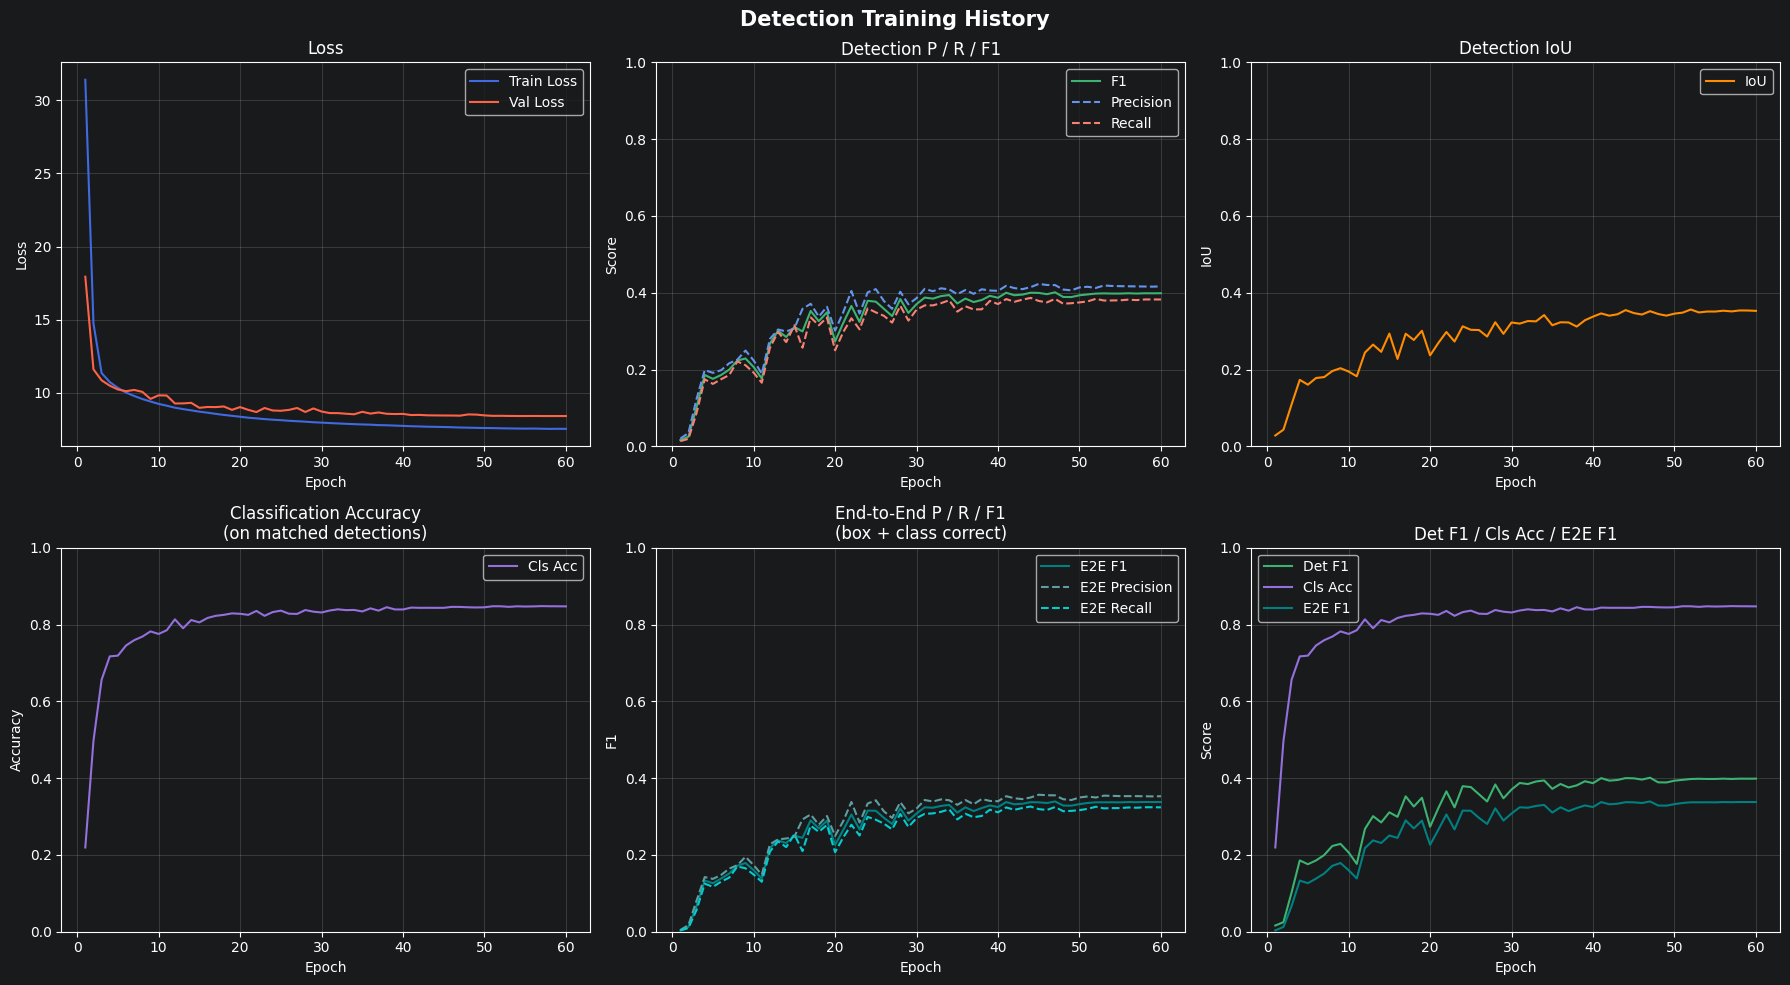

In [6]:
# Full detection training dashboard (Loss, Det P/R/F1, IoU, Cls Acc, E2E P/R/F1)
Visualizer.visualize_detection_history(history)


## 6 · Final Evaluation on Test Set


In [7]:
# Load best checkpoint weights if checkpoint callback was used
if 'checkpoint' in locals() and checkpoint is not None:
    checkpoint.restore_best_weights()

metrics = evaluate_detection(model, test_loader, criterion, DEVICE, conf_threshold=CONF_THRESH)

det = metrics['detection']
cls = metrics['classification']
e2e = metrics['end_to_end']

print('=== Detection (localisation) ===')
print(f"  Loss     : {metrics['loss']:.4f}")
print(f"  IoU      : {det['iou']:.4f}")
print(f"  Precision: {det['precision']:.4f}")
print(f"  Recall   : {det['recall']:.4f}")
print(f"  F1       : {det['f1']:.4f}")
print(f"  TP/FP/FN : {det['tp']} / {det['fp']} / {det['fn']}")

print('\n=== Classification (on matched detections) ===')
print(f"  Accuracy : {cls['accuracy']:.4f}")
print('  Per-class:')
for k, v in cls['per_class'].items():
    name = v.get('name', f'class_{k}')
    print(f"    [{k}] {name}: acc={v['accuracy']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}  e2e_f1={v['e2e_f1']:.4f}")

print('\n=== End-to-End (box + class correct) ===')
print(f"  Precision: {e2e['precision']:.4f}")
print(f"  Recall   : {e2e['recall']:.4f}")
print(f"  F1       : {e2e['f1']:.4f}")
print(f"  TP/FP/FN : {e2e['tp']} / {e2e['fp']} / {e2e['fn']}")


=== Detection (localisation) ===
  Loss     : 8.3546
  IoU      : 0.3564
  Precision: 0.4262
  Recall   : 0.3910
  F1       : 0.4078
  TP/FP/FN : 140971 / 189801 / 219596

=== Classification (on matched detections) ===
  Accuracy : 0.8408
  Per-class:
    [0] class_0: acc=0.7564  e2e_p=0.2685  e2e_r=0.3099  e2e_f1=0.2877
    [1] class_1: acc=0.7247  e2e_p=0.2270  e2e_r=0.2857  e2e_f1=0.2530
    [2] class_2: acc=0.8484  e2e_p=0.3948  e2e_r=0.3602  e2e_f1=0.3767
    [3] class_3: acc=0.9445  e2e_p=0.4268  e2e_r=0.4048  e2e_f1=0.4155
    [4] class_4: acc=0.8841  e2e_p=0.4056  e2e_r=0.3795  e2e_f1=0.3921
    [5] class_5: acc=0.8413  e2e_p=0.4117  e2e_r=0.3661  e2e_f1=0.3876
    [6] class_6: acc=0.8883  e2e_p=0.4152  e2e_r=0.3789  e2e_f1=0.3962
    [7] class_7: acc=0.9330  e2e_p=0.4143  e2e_r=0.3878  e2e_f1=0.4006
    [8] class_8: acc=0.9043  e2e_p=0.4074  e2e_r=0.3817  e2e_f1=0.3941
    [9] class_9: acc=0.6510  e2e_p=0.3336  e2e_r=0.2653  e2e_f1=0.2955
    [10] class_10: acc=0.9261  e2e_p=0

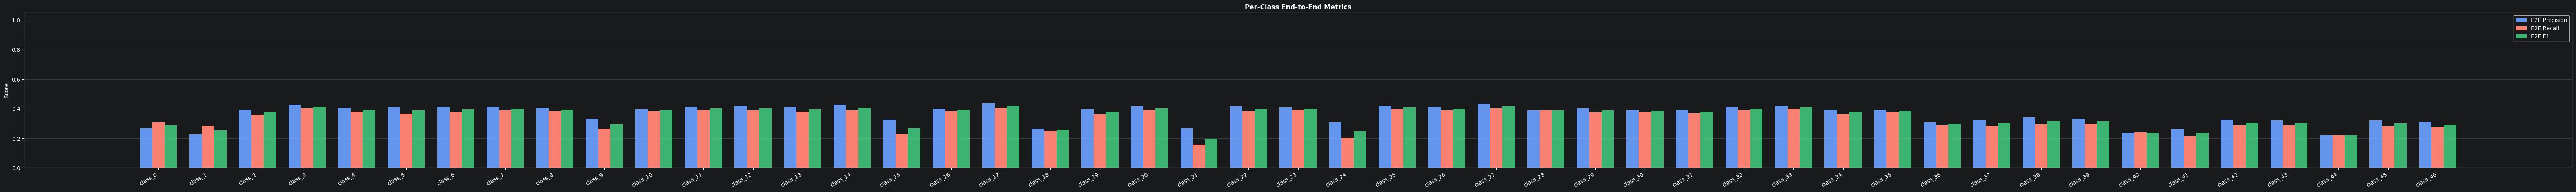

In [8]:
Visualizer.visualize_per_class_e2e(metrics)

## 7 · Prediction Visualisation

- **Lime** boxes = ground truth
- **Red** (dashed) boxes = model predictions with `conf > CONF_THRESH` (plus NMS)


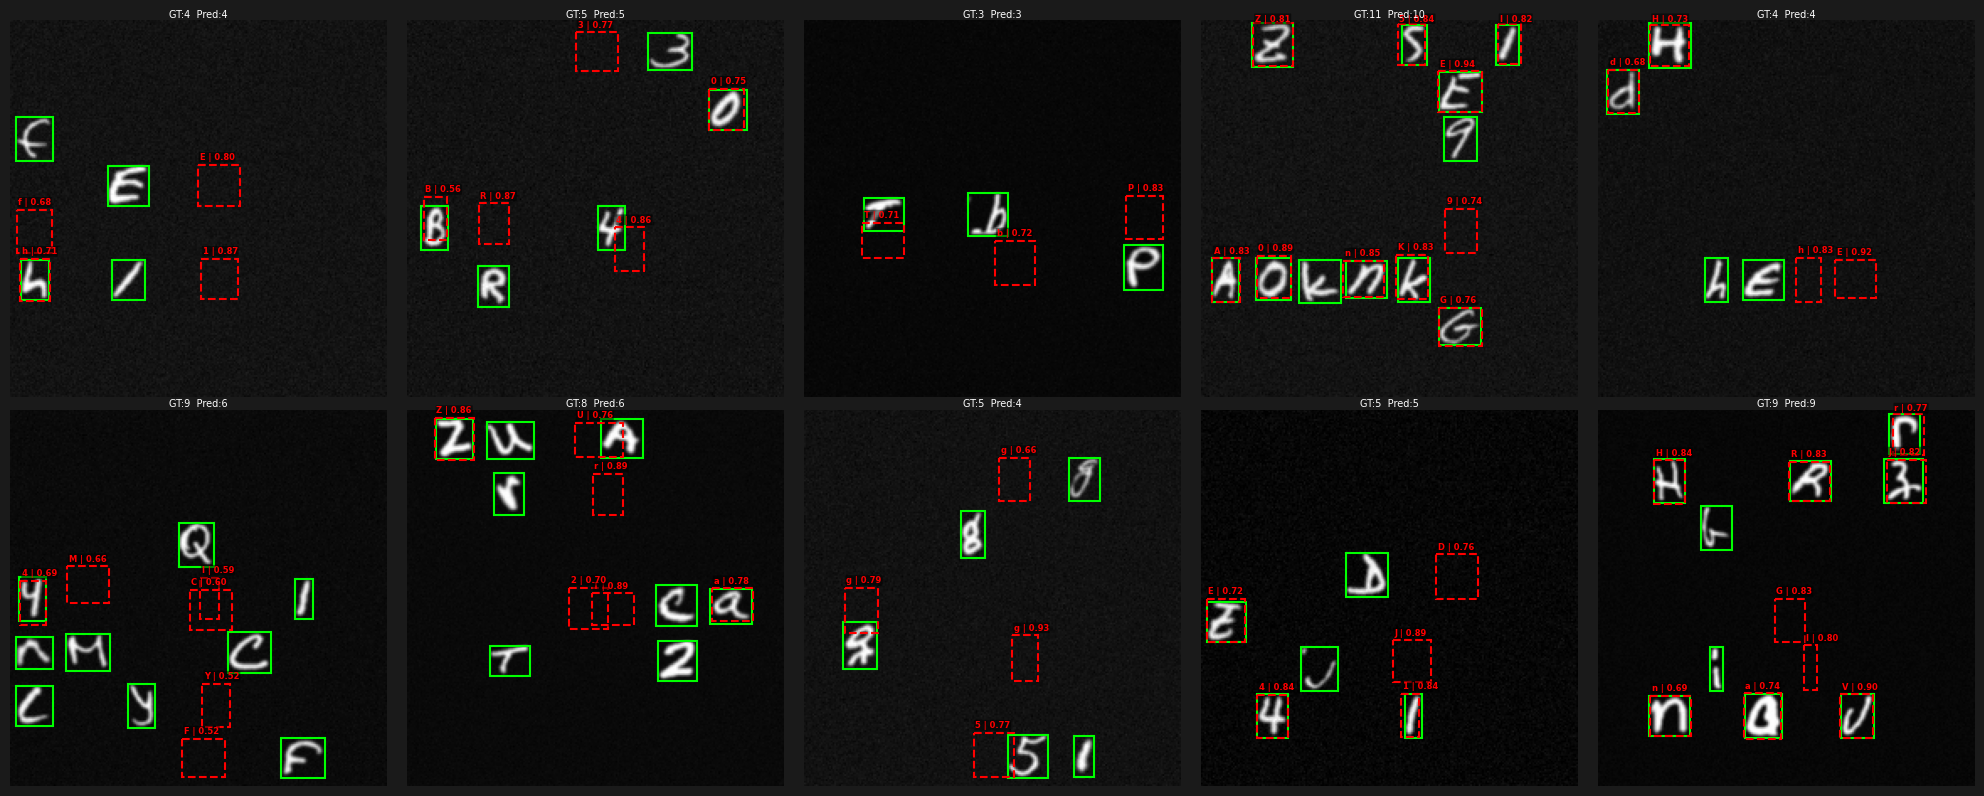

In [9]:
test_batch = next(iter(test_loader))
imgs_t, targets_t, labels_t = test_batch
with torch.no_grad():
    preds_t = model(imgs_t.to(DEVICE)).cpu()

Visualizer.visualize_multi_detection_batch(
    imgs_v=imgs_t,
    preds=preds_t,
    gt_grid=targets_t,
    conf_thresh=CONF_THRESH,
    class_names=CLASS_NAMES,
)


## 8 · Confidence Threshold Sweep

Sweeps confidence thresholds on the held-out **test set** to evaluate the full Precision / Recall / F1 trade-off.


In [10]:
sweep_results = evaluate_detection_sweep(
    model, test_loader, DEVICE,
    conf_thresholds=np.arange(0.1, 0.95, 0.05),
    iou_threshold=0.5,
    print_table=True,
)

if 'logger' in locals() and logger is not None:
    logger.log_test_results(sweep_results, iou_threshold=0.5)



  Conf       P       R      F1   ClsAcc       TP       FP       FN
------------------------------------------------------------------
  0.10  0.2980  0.4357  0.3540   0.8330   157111   370041   203456
  0.15  0.3274  0.4310  0.3721   0.8346   155399   319183   205168
  0.20  0.3486  0.4270  0.3838   0.8358   153962   287747   206605
  0.25  0.3650  0.4235  0.3920   0.8369   152687   265686   207880
  0.30  0.3796  0.4197  0.3986   0.8378   151333   247341   209234
  0.35  0.3931  0.4150  0.4037   0.8385   149626   230998   210941
  0.40  0.4057  0.4087  0.4072   0.8393   147355   215892   213212
  0.45  0.4154  0.4017  0.4084   0.8398   144836   203835   215731
  0.50  0.4262  0.3910  0.4078   0.8408   140971   189801   219596
  0.55  0.4352  0.3797  0.4055   0.8418   136905   177691   223662
  0.60  0.4441  0.3665  0.4016   0.8429   132149   165400   228418
  0.65  0.4552  0.3473  0.3940   0.8440   125209   149829   235358
  0.70  0.4674  0.3154  0.3766   0.8450   113719   129600   2

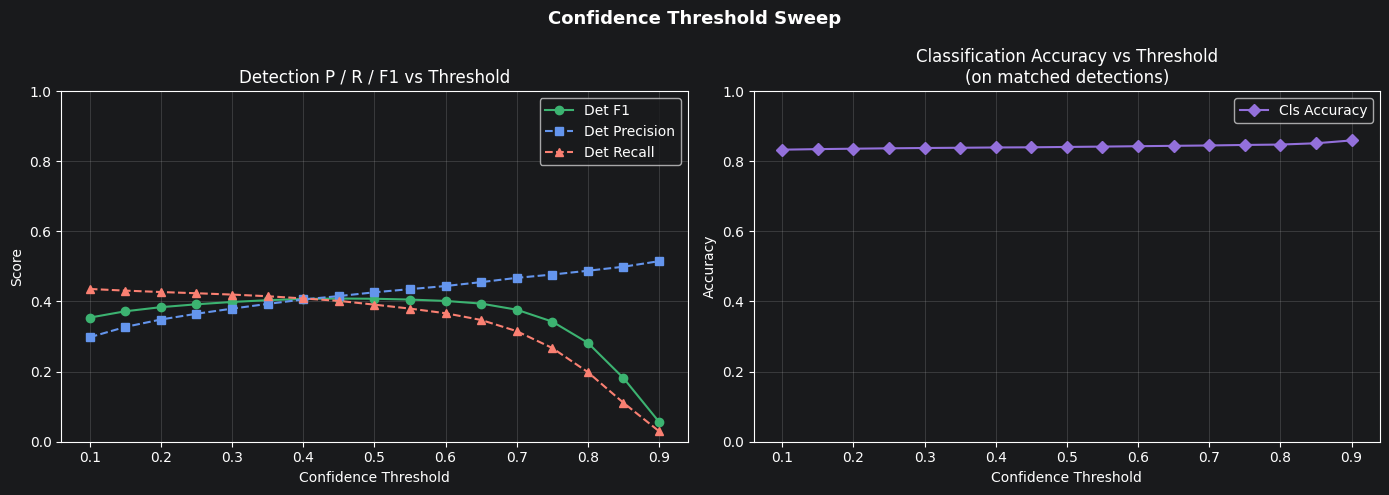


Best conf threshold : 0.45
  Det  F1  = 0.4084
  Cls  Acc = 0.8398
Per-class E2E F1:
  [0] class_0: e2e_f1=0.2871  e2e_p=0.2623  e2e_r=0.3171
  [1] class_1: e2e_f1=0.2520  e2e_p=0.2215  e2e_r=0.2923
  [2] class_2: e2e_f1=0.3761  e2e_p=0.3858  e2e_r=0.3669
  [3] class_3: e2e_f1=0.4156  e2e_p=0.4159  e2e_r=0.4153
  [4] class_4: e2e_f1=0.3917  e2e_p=0.3973  e2e_r=0.3862
  [5] class_5: e2e_f1=0.3876  e2e_p=0.4027  e2e_r=0.3736
  [6] class_6: e2e_f1=0.3963  e2e_p=0.4054  e2e_r=0.3876
  [7] class_7: e2e_f1=0.4014  e2e_p=0.4047  e2e_r=0.3982
  [8] class_8: e2e_f1=0.3938  e2e_p=0.3995  e2e_r=0.3883
  [9] class_9: e2e_f1=0.2973  e2e_p=0.3271  e2e_r=0.2724
  [10] class_10: e2e_f1=0.3907  e2e_p=0.3903  e2e_r=0.3912
  [11] class_11: e2e_f1=0.4029  e2e_p=0.4046  e2e_r=0.4011
  [12] class_12: e2e_f1=0.4035  e2e_p=0.4093  e2e_r=0.3979
  [13] class_13: e2e_f1=0.3973  e2e_p=0.4040  e2e_r=0.3908
  [14] class_14: e2e_f1=0.4098  e2e_p=0.4220  e2e_r=0.3983
  [15] class_15: e2e_f1=0.2706  e2e_p=0.3205  e2e

In [11]:
# Plot Det P/R/F1 and Cls Accuracy across thresholds
Visualizer.visualize_sweep_results(sweep_results)

# Per-class E2E F1 at best Det-F1 threshold
best_r = max(sweep_results, key=lambda r: r['f1'])
print(f"\nBest conf threshold : {best_r['conf']:.2f}")
print(f"  Det  F1  = {best_r['f1']:.4f}")
print(f"  Cls  Acc = {best_r['cls_accuracy']:.4f}")
print('Per-class E2E F1:')
for k, v in best_r['per_class_e2e'].items():
    name = v.get('name', f'class_{k}')
    print(f"  [{k}] {name}: e2e_f1={v['e2e_f1']:.4f}  "
          f"e2e_p={v['e2e_precision']:.4f}  e2e_r={v['e2e_recall']:.4f}")
